# Exploratory Data Analysis (EDA)

Analysis of the **IBM Telco Customer Churn** dataset. This notebook explores the
data; the cleaning and feature-engineering steps live in
`02_data_preprocessing_feature_engineering.ipynb`.

**Objectives**
- Assess data quality (missing values, duplicates, constant / high-cardinality columns)
- Profile categorical and numerical features
- Compare churned vs. non-churned customers
- Examine correlations between numerical features

**Dataset note:** `Total Charges` contains 11 blank values, all belonging to
customers with `Tenure Months` = 0. They are coerced to `NaN` here and those
rows are excluded from numerical plots. The preprocessing notebook imputes them
with 0 and keeps all 7,043 rows.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")

df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

print("Dataset loaded successfully!")
print(f"Total Charges blanks coerced to NaN: {df['Total Charges'].isnull().sum()}")

Dataset loaded successfully!
Total Charges blanks coerced to NaN: 11


In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [4]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 7043
Columns: 33


In [5]:
df.columns.tolist()

['CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason']

In [6]:
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

# Data Quality Assessment

In [8]:
missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().mean() * 100).round(2)
})

missing_df = missing_df[missing_df["Missing Values"] > 0]

missing_df.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
Churn Reason,5174,73.46
Total Charges,11,0.16


In [9]:
# Duplicate Records
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [10]:
# Unique Values
df.nunique().sort_values()

Count                   1
Country                 1
State                   1
Phone Service           2
Dependents              2
Partner                 2
Senior Citizen          2
Gender                  2
Churn Value             2
Paperless Billing       2
Churn Label             2
Multiple Lines          3
Internet Service        3
Online Backup           3
Online Security         3
Tech Support            3
Contract                3
Streaming Movies        3
Streaming TV            3
Device Protection       3
Payment Method          4
Churn Reason           20
Tenure Months          73
Churn Score            85
City                 1129
Monthly Charges      1585
Longitude            1651
Latitude             1652
Lat Long             1652
Zip Code             1652
CLTV                 3438
Total Charges        6530
CustomerID           7043
dtype: int64

In [11]:
# Constant Columns
constant_columns = [
    col
    for col in df.columns
    if df[col].nunique() == 1
]

constant_columns

['Count', 'Country', 'State']

In [12]:
# High Cardinality
df.nunique().sort_values(ascending=False)

CustomerID           7043
Total Charges        6530
CLTV                 3438
Lat Long             1652
Latitude             1652
Zip Code             1652
Longitude            1651
Monthly Charges      1585
City                 1129
Churn Score            85
Tenure Months          73
Churn Reason           20
Payment Method          4
Online Backup           3
Online Security         3
Multiple Lines          3
Internet Service        3
Tech Support            3
Contract                3
Streaming Movies        3
Streaming TV            3
Device Protection       3
Senior Citizen          2
Partner                 2
Dependents              2
Gender                  2
Paperless Billing       2
Churn Label             2
Phone Service           2
Churn Value             2
Count                   1
Country                 1
State                   1
dtype: int64

In [13]:
feature_inventory = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": [df[col].nunique() for col in df.columns],
    "Missing Values": [df[col].isnull().sum() for col in df.columns]
})

feature_inventory

,Feature,Data Type,Unique Values,Missing Values
0,CustomerID,object,7043,0
1,Count,int64,1,0
2,Country,object,1,0
3,State,object,1,0
4,City,object,1129,0
5,Zip Code,int64,1652,0
6,Lat Long,object,1652,0
7,Latitude,float64,1652,0
8,Longitude,float64,1651,0
9,Gender,object,2,0


In [14]:
feature_classification = {
    "CustomerID": "Identifier",
    "Count": "Constant",
    "Country": "Constant",
    "State": "Constant",
    "City": "Geographic",
    "Zip Code": "Geographic",
    "Lat Long": "Redundant",
    "Latitude": "Geographic",
    "Longitude": "Geographic",
    "Gender": "Categorical",
    "Senior Citizen": "Categorical",
    "Partner": "Categorical",
    "Dependents": "Categorical",
    "Tenure Months": "Numerical",
    "Phone Service": "Categorical",
    "Multiple Lines": "Categorical",
    "Internet Service": "Categorical",
    "Online Security": "Categorical",
    "Online Backup": "Categorical",
    "Device Protection": "Categorical",
    "Tech Support": "Categorical",
    "Streaming TV": "Categorical",
    "Streaming Movies": "Categorical",
    "Contract": "Categorical",
    "Paperless Billing": "Categorical",
    "Payment Method": "Categorical",
    "Monthly Charges": "Numerical",
    "Total Charges": "Numerical",
    "CLTV": "Business Metric",
    "Churn Score": "Leakage",
    "Churn Reason": "Leakage",
    "Churn Value": "Target (Numeric)",
    "Churn Label": "Target",
}

pd.DataFrame(feature_classification.items(), columns=["Feature", "Category"])

,Feature,Category
0,CustomerID,Identifier
1,Count,Constant
2,Country,Constant
3,State,Constant
4,City,Geographic
5,Zip Code,Geographic
6,Lat Long,Redundant
7,Latitude,Geographic
8,Longitude,Geographic
9,Gender,Categorical


# Univariate Analysis

In [15]:
# Target Variable Analysis
target_counts = df["Churn Label"].value_counts()

target_counts

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [16]:
target_percentage = (
    df["Churn Label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_percentage

Churn Label
No     73.46
Yes    26.54
Name: proportion, dtype: float64

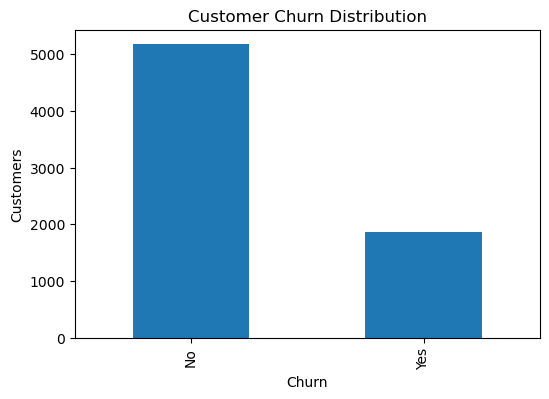

In [17]:
# Bar Chart
plt.figure(figsize=(6, 4))

df["Churn Label"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customers")

plt.show()

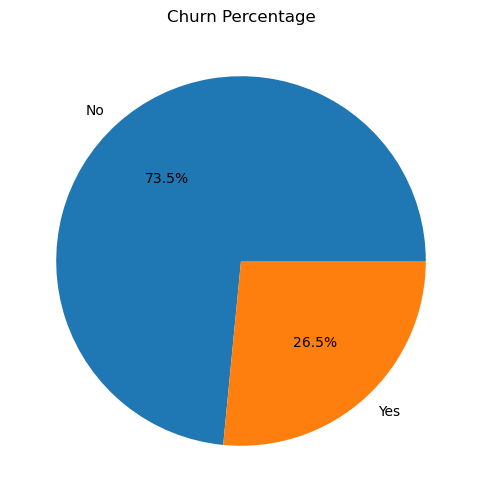

In [18]:
# Pie Chart
plt.figure(figsize=(6, 6))

df["Churn Label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Churn Percentage")

plt.show()

## Business Interpretation

Around one-quarter of customers have churned, while the majority remain active.
The target is moderately imbalanced, but not severe enough to prevent effective
model training. During evaluation we should report metrics beyond accuracy, such
as Precision, Recall, and F1-score.

In [19]:
# Categorical Feature Analysis
# Create a Feature List
categorical_features = [

    "Gender",

    "Senior Citizen",

    "Partner",

    "Dependents",

    "Phone Service",

    "Multiple Lines",

    "Internet Service",

    "Online Security",

    "Online Backup",

    "Device Protection",

    "Tech Support",

    "Streaming TV",

    "Streaming Movies",

    "Contract",

    "Paperless Billing",

    "Payment Method"

]

In [20]:
for feature in categorical_features:
    print("=" * 60)
    print(feature)
    print("=" * 60)
    print(df[feature].value_counts())
    print()
    print(df[feature].value_counts(normalize=True) * 100)
    print("\n")

Gender
Gender
Male      3555
Female    3488
Name: count, dtype: int64

Gender
Male      50.47565
Female    49.52435
Name: proportion, dtype: float64


Senior Citizen
Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64

Senior Citizen
No     83.785319
Yes    16.214681
Name: proportion, dtype: float64


Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Partner
No     51.69672
Yes    48.30328
Name: proportion, dtype: float64


Dependents
Dependents
No     5416
Yes    1627
Name: count, dtype: int64

Dependents
No     76.899049
Yes    23.100951
Name: proportion, dtype: float64


Phone Service
Phone Service
Yes    6361
No      682
Name: count, dtype: int64

Phone Service
Yes    90.316626
No      9.683374
Name: proportion, dtype: float64


Multiple Lines
Multiple Lines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Multiple Lines
No                  48.132898
Yes                 42.183729
No phone service    

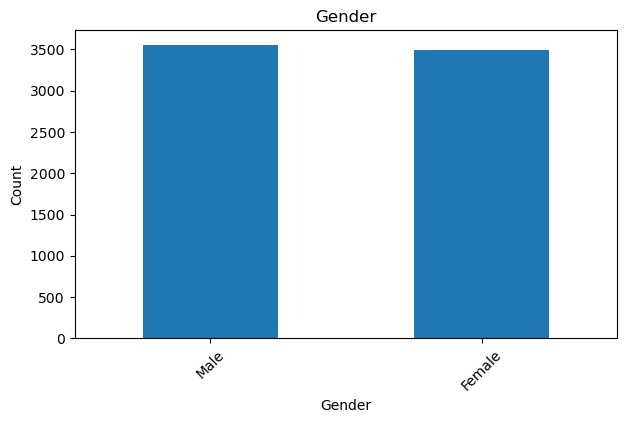

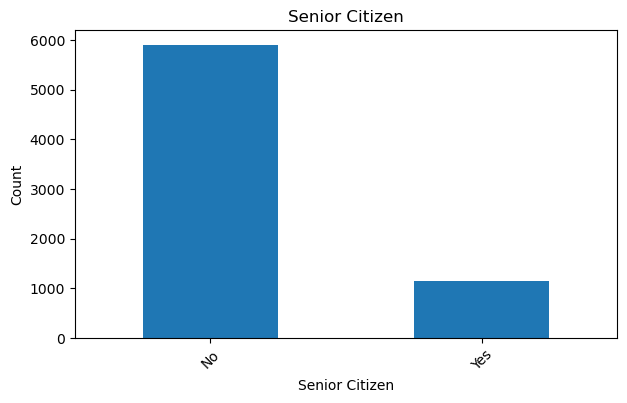

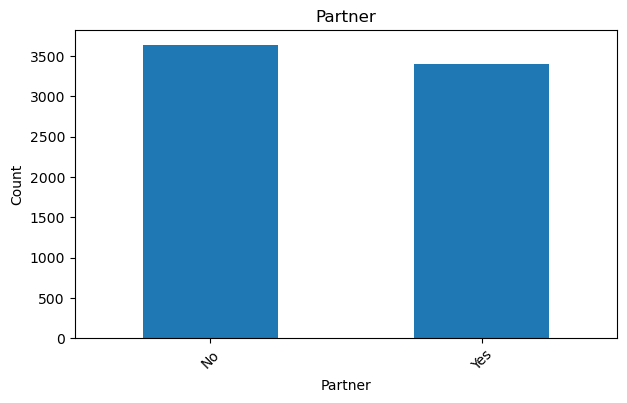

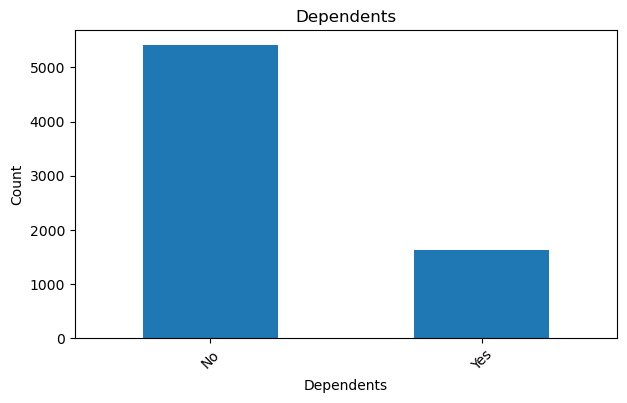

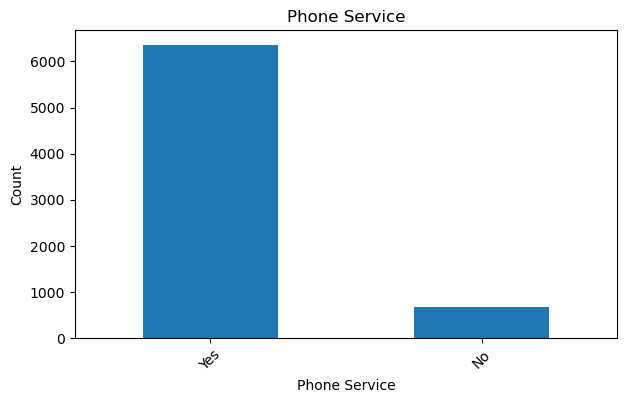

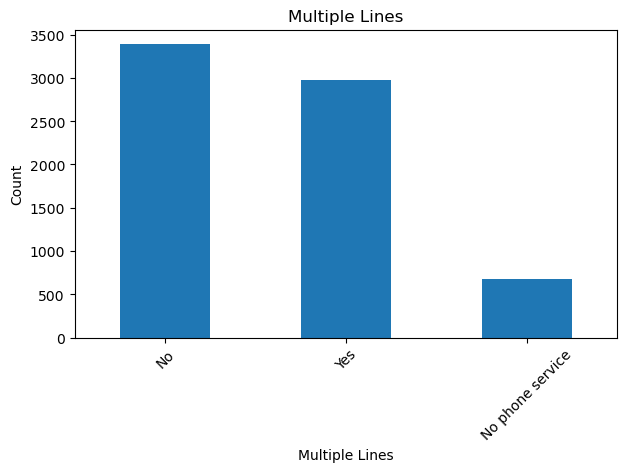

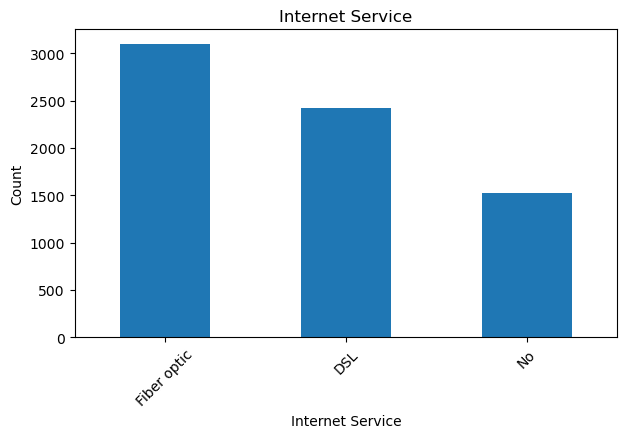

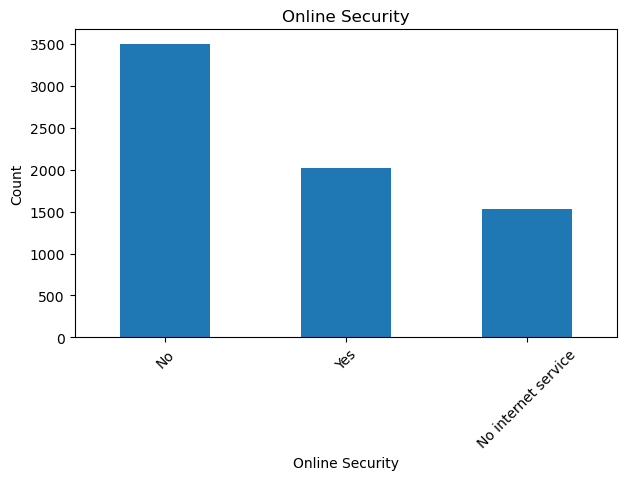

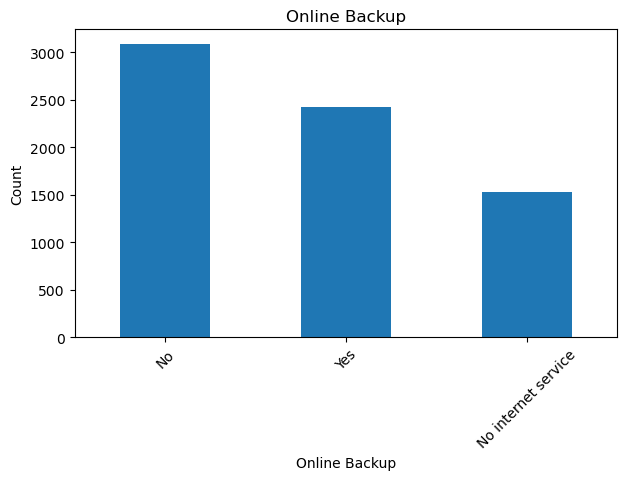

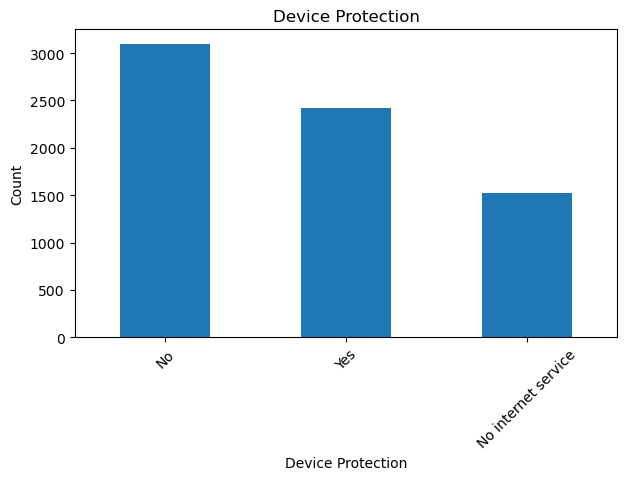

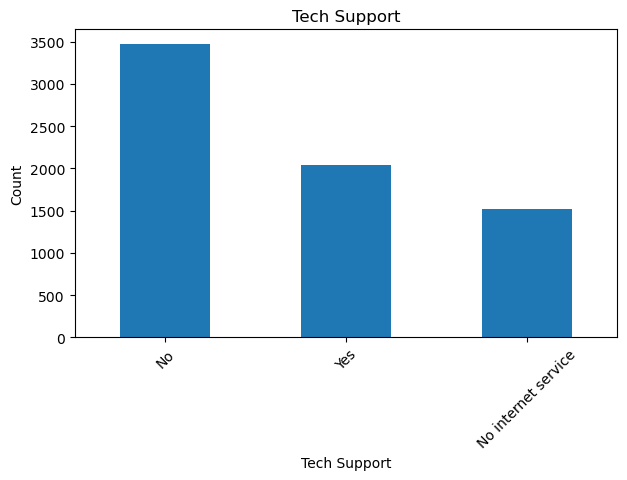

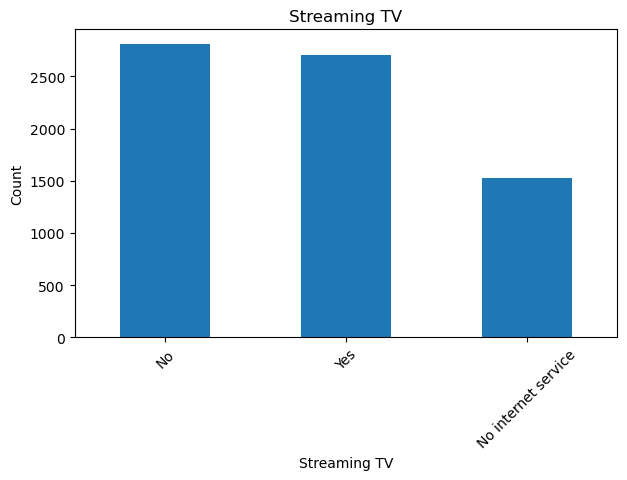

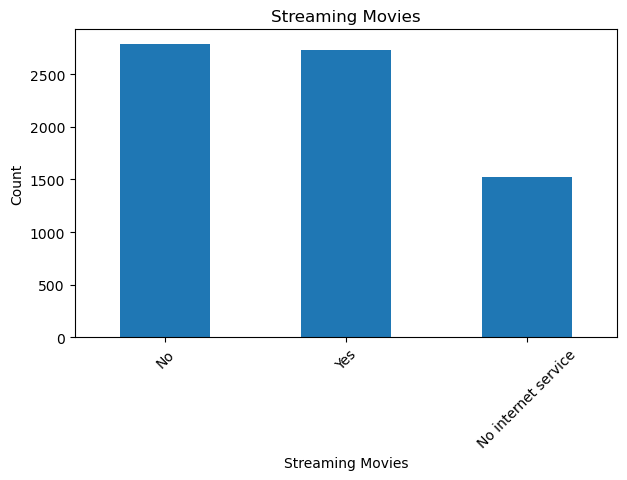

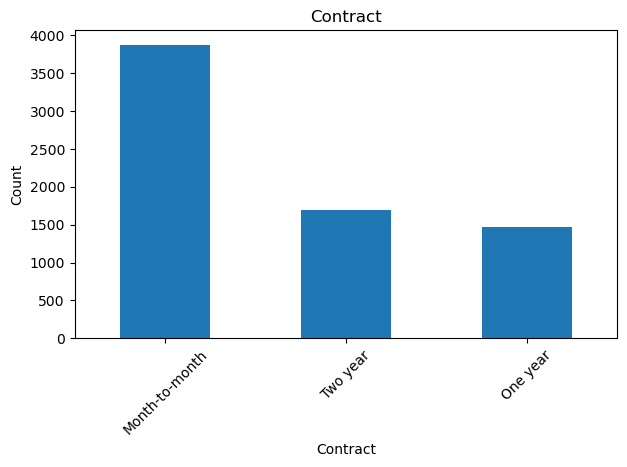

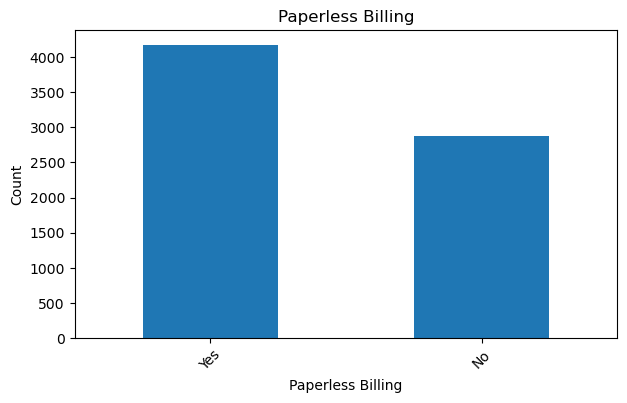

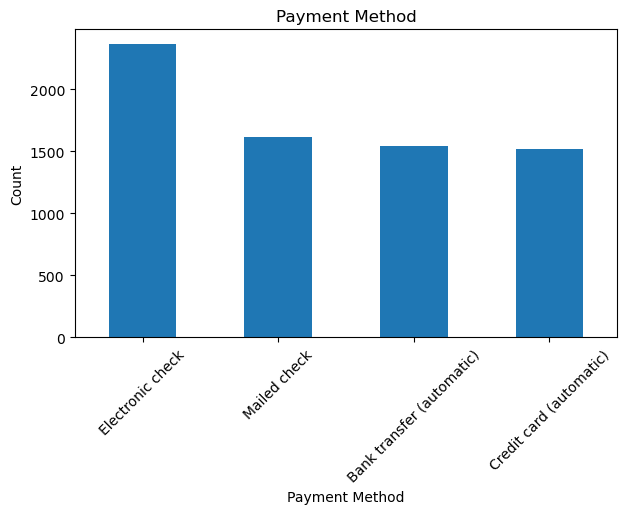

In [21]:
# Visualizing Categorical Features
for feature in categorical_features:
    plt.figure(figsize=(7, 4))
    df[feature].value_counts().plot(kind="bar")
    plt.title(feature)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

In [22]:
# Numerical Feature Analysis
numerical_features = [

    "Tenure Months",

    "Monthly Charges",

    "Total Charges",

    "CLTV"

]

In [23]:
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Tenure Months,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
Monthly Charges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
Total Charges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80
CLTV,7043.0,4400.295755,1183.057152,2003.00,3469.00,4527.000,5380.5000,6500.00


In [24]:
# Coercion happened when loading; confirm the blanks became NaN.
df["Total Charges"].isnull().sum()

np.int64(11)

In [25]:
df.dropna(subset=["Total Charges"], inplace=True)

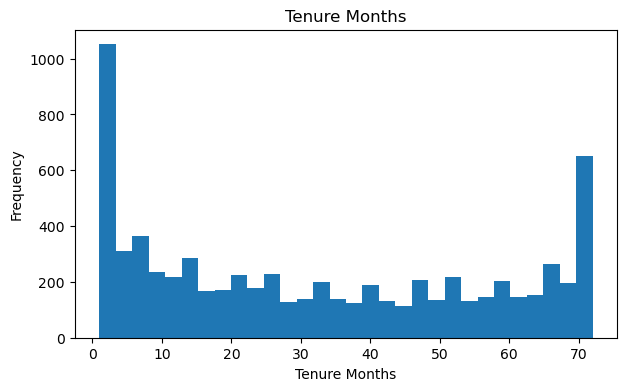

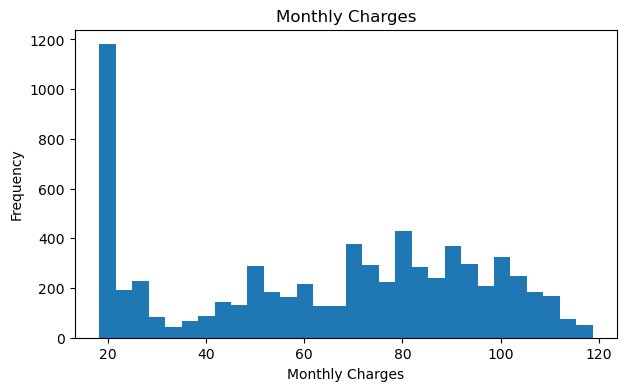

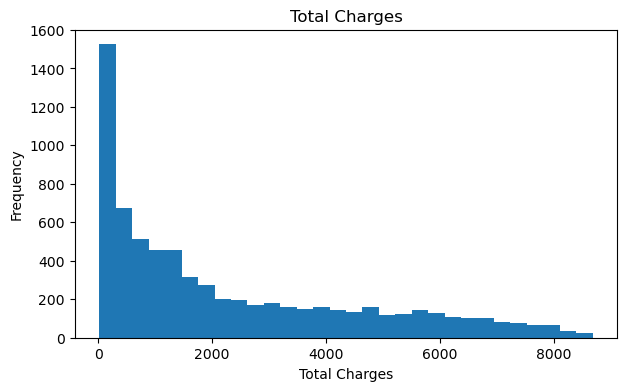

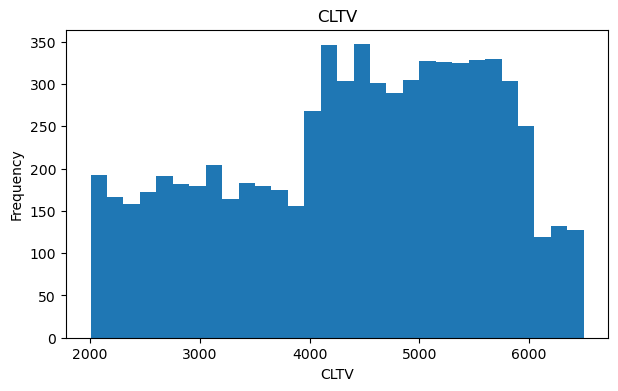

In [26]:
# Histograms
for feature in numerical_features:
    plt.figure(figsize=(7, 4))
    plt.hist(df[feature], bins=30)
    plt.title(feature)
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

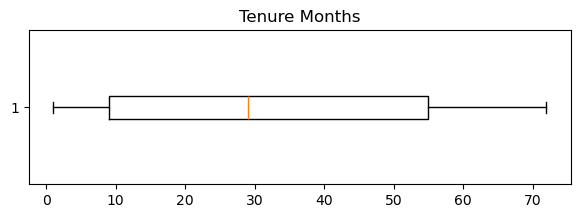

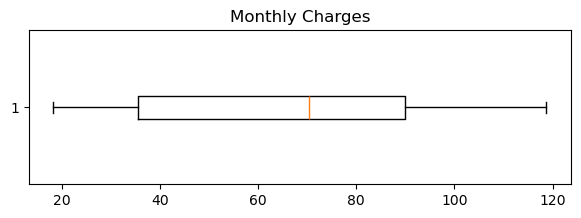

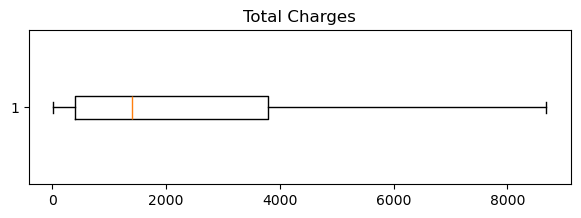

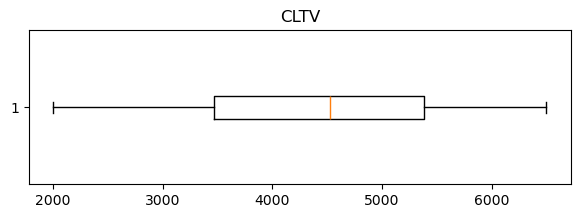

In [27]:
# BoxPlots
for feature in numerical_features:
    plt.figure(figsize=(7, 2))
    plt.boxplot(df[feature], vert=False)
    plt.title(feature)
    plt.show()

# Bivariate Analysis: Categorical Features vs Churn

In [28]:
# Generate Crosstabs
for feature in categorical_features:
    print("=" * 70)
    print(feature)
    print("=" * 70)

    table = pd.crosstab(
        df[feature],
        df["Churn Label"],
        normalize="index"
    ) * 100

    print(table.round(2))
    print("\n")

Gender
Churn Label     No    Yes
Gender                   
Female       73.04  26.96
Male         73.80  26.20


Senior Citizen
Churn Label        No    Yes
Senior Citizen              
No              76.35  23.65
Yes             58.32  41.68


Partner
Churn Label     No    Yes
Partner                  
No           67.02  32.98
Yes          80.28  19.72


Dependents
Churn Label     No    Yes
Dependents               
No           67.42  32.58
Yes          93.46   6.54


Phone Service
Churn Label       No    Yes
Phone Service              
No             75.00  25.00
Yes            73.25  26.75


Multiple Lines
Churn Label          No    Yes
Multiple Lines                
No                74.92  25.08
No phone service  75.00  25.00
Yes               71.35  28.65


Internet Service
Churn Label          No    Yes
Internet Service              
DSL               81.00  19.00
Fiber optic       58.11  41.89
No                92.57   7.43


Online Security
Churn Label             No    Yes

<Figure size 800x400 with 0 Axes>

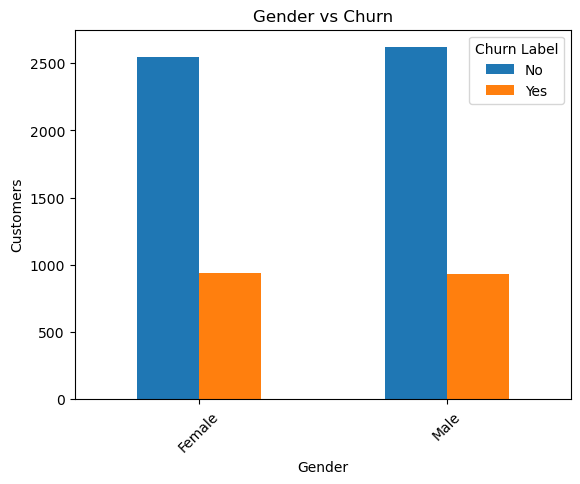

<Figure size 800x400 with 0 Axes>

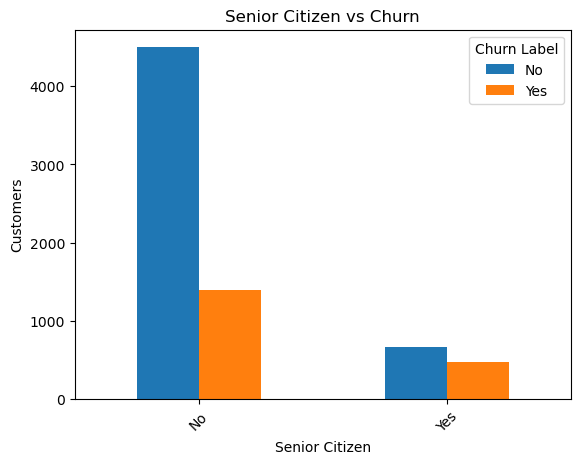

<Figure size 800x400 with 0 Axes>

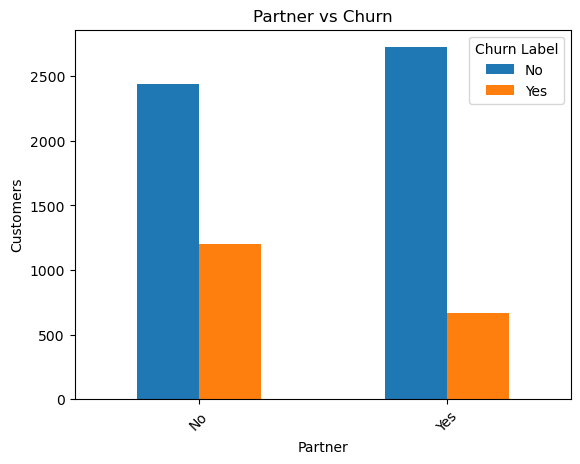

<Figure size 800x400 with 0 Axes>

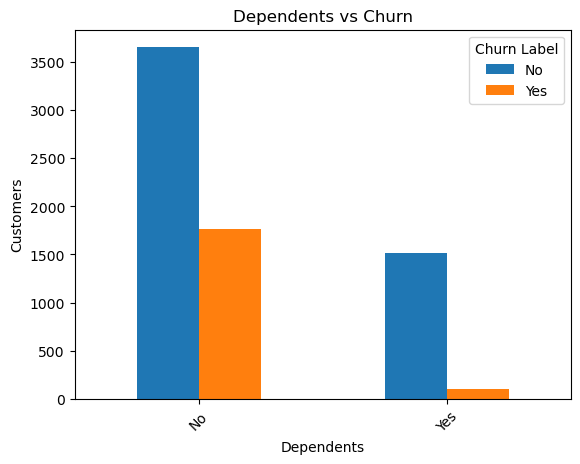

<Figure size 800x400 with 0 Axes>

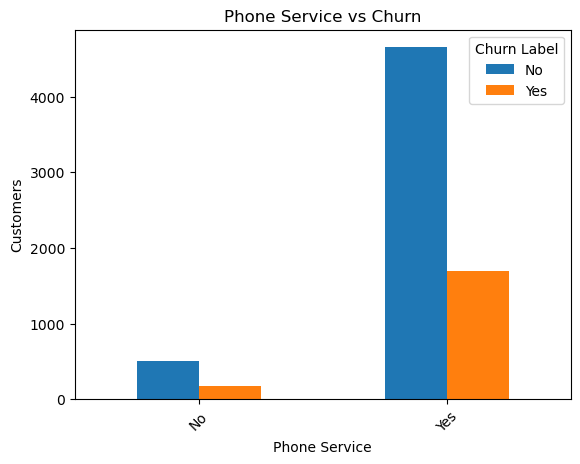

<Figure size 800x400 with 0 Axes>

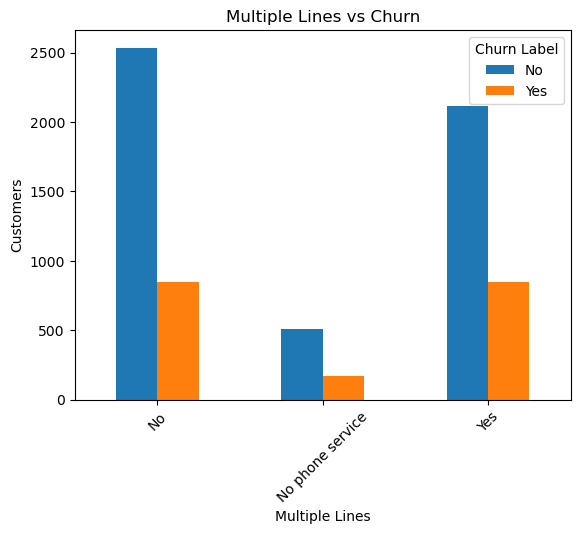

<Figure size 800x400 with 0 Axes>

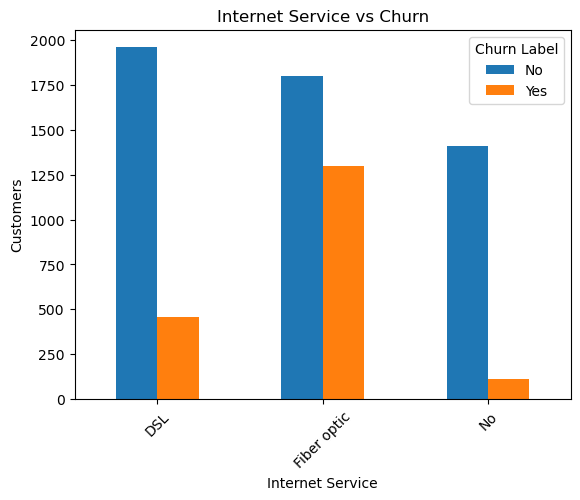

<Figure size 800x400 with 0 Axes>

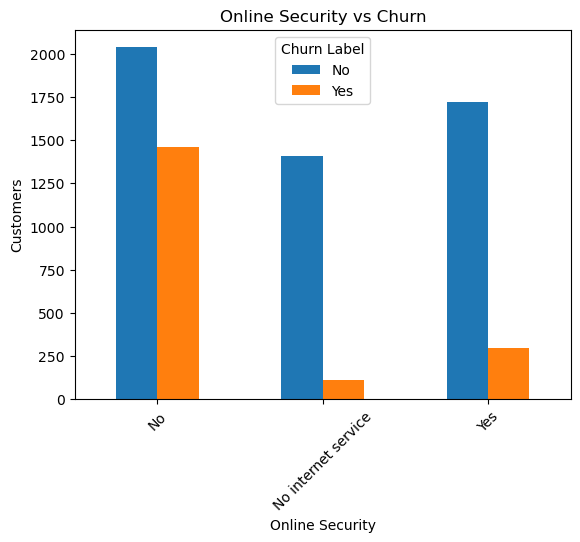

<Figure size 800x400 with 0 Axes>

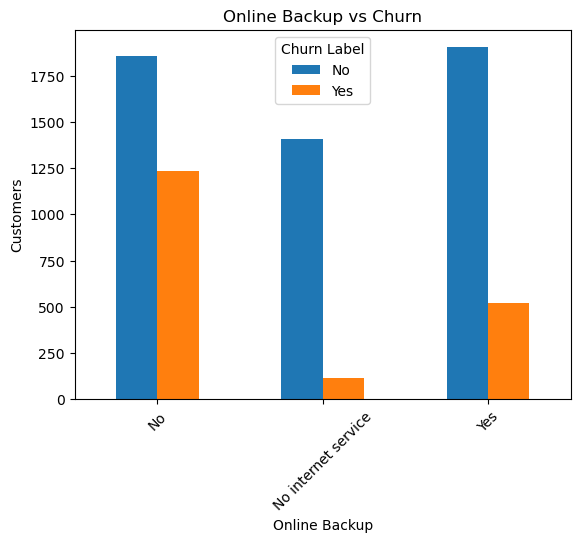

<Figure size 800x400 with 0 Axes>

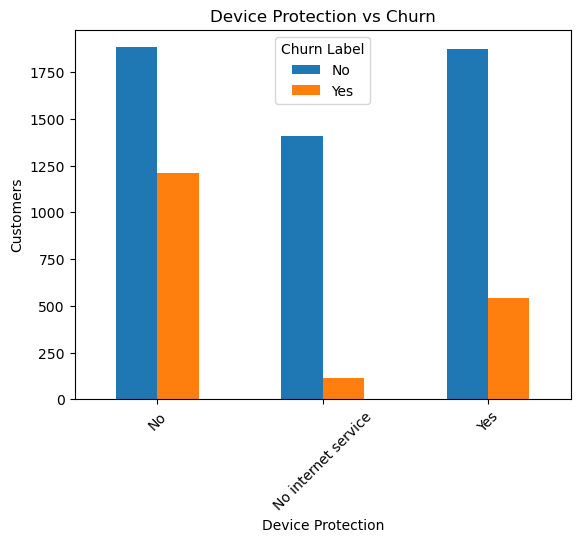

<Figure size 800x400 with 0 Axes>

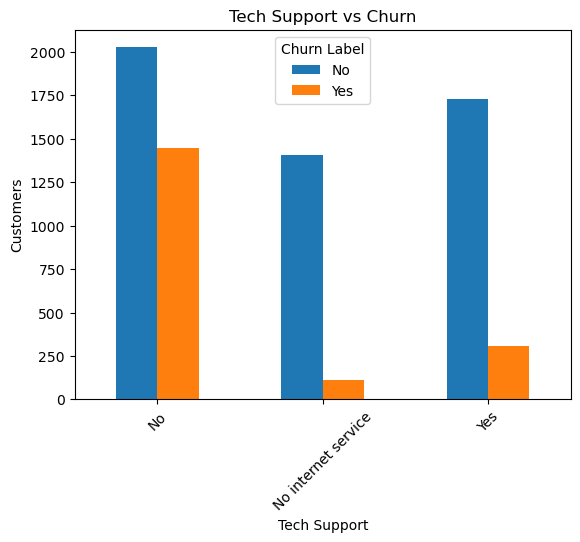

<Figure size 800x400 with 0 Axes>

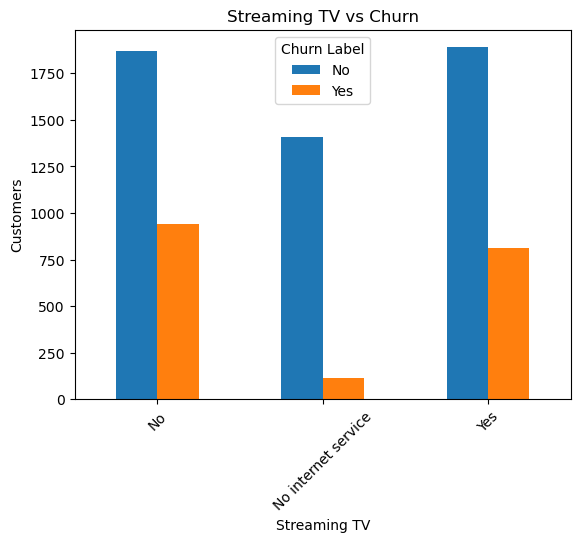

<Figure size 800x400 with 0 Axes>

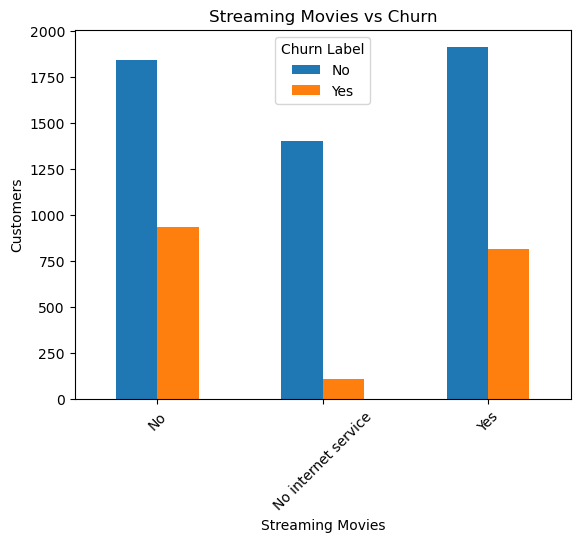

<Figure size 800x400 with 0 Axes>

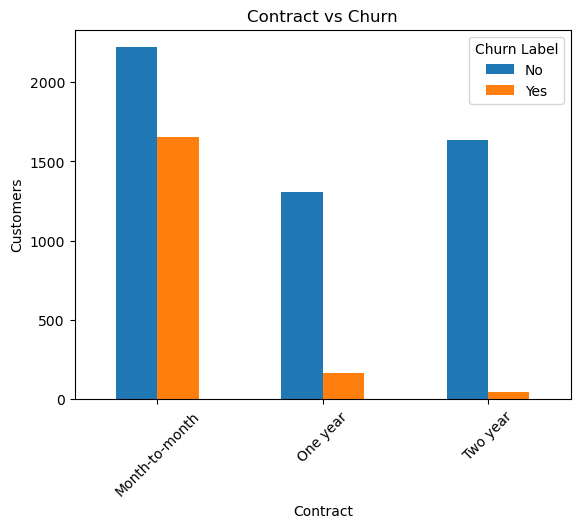

<Figure size 800x400 with 0 Axes>

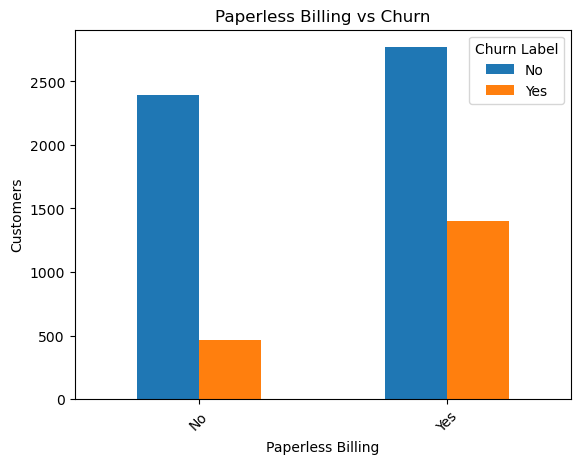

<Figure size 800x400 with 0 Axes>

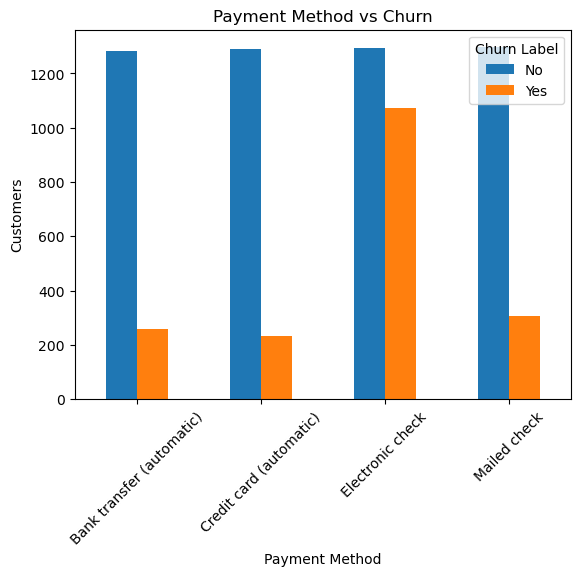

In [29]:
for feature in categorical_features:
    plt.figure(figsize=(8, 4))
    pd.crosstab(df[feature], df["Churn Label"]).plot(kind="bar")
    plt.title(feature + " vs Churn")
    plt.ylabel("Customers")
    plt.xticks(rotation=45)
    plt.show()

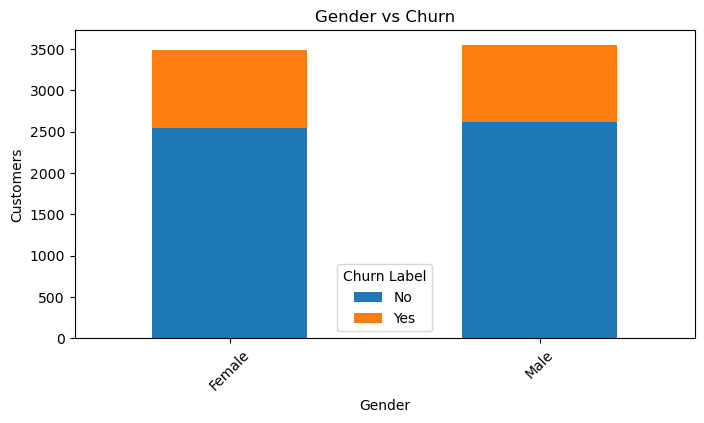

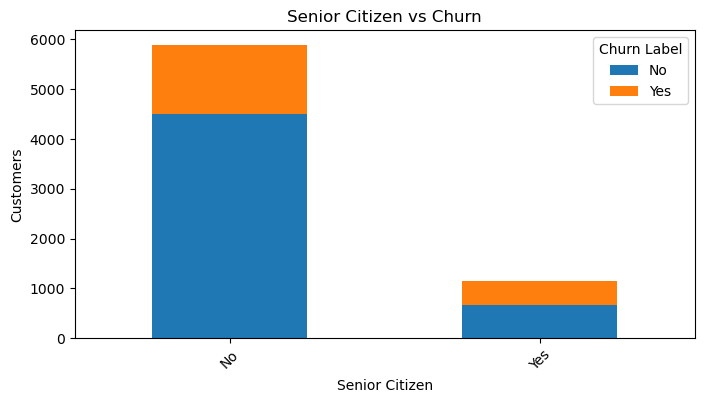

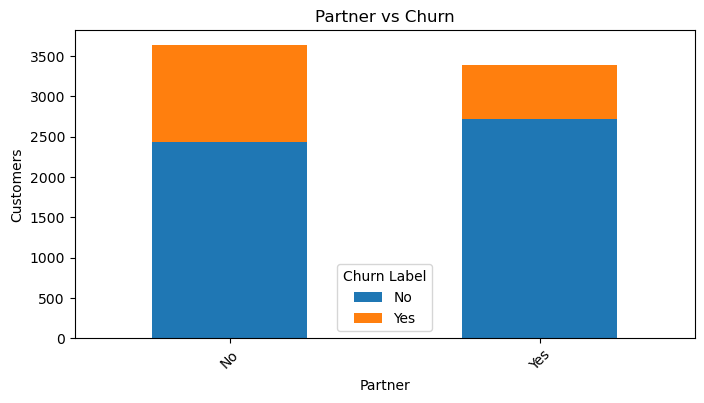

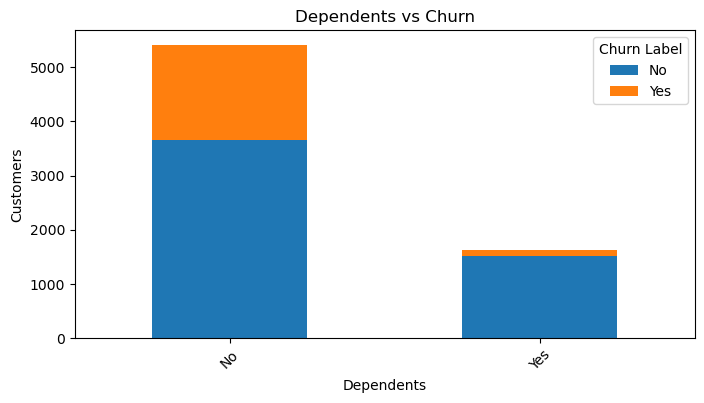

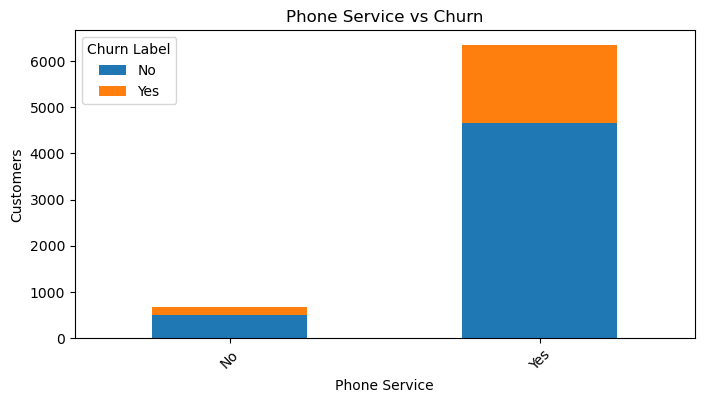

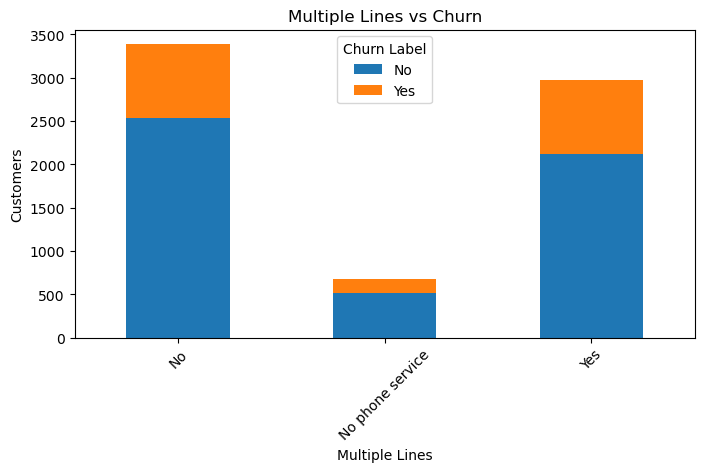

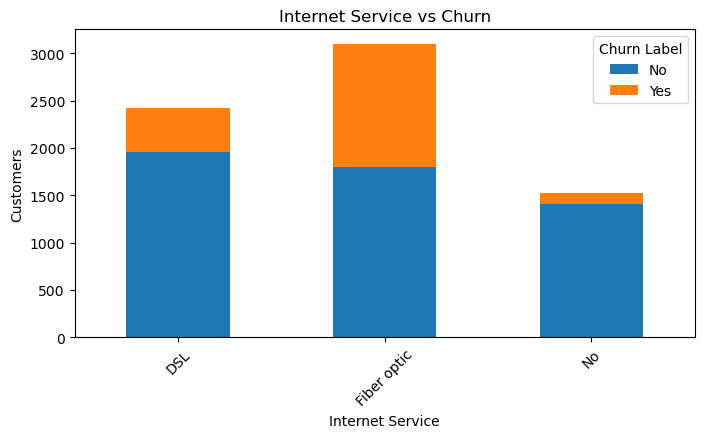

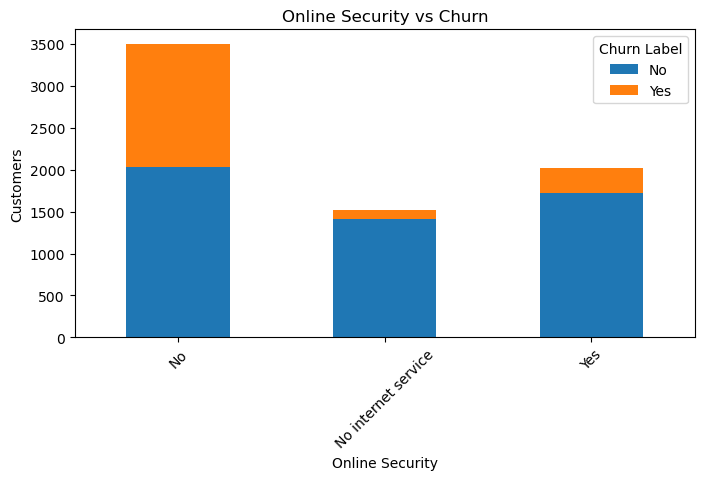

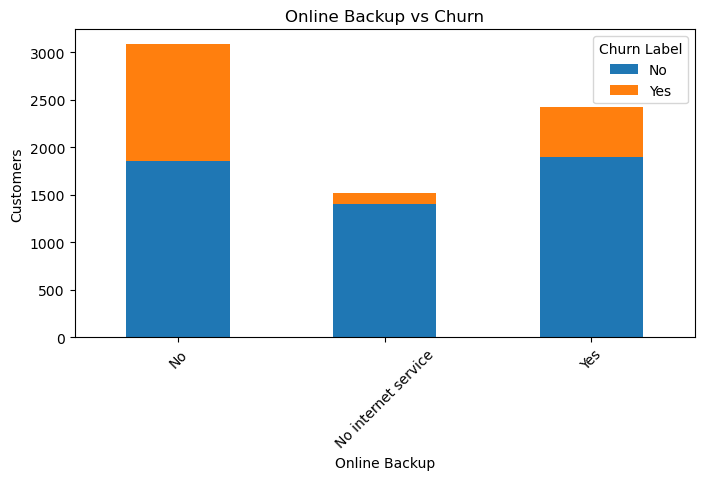

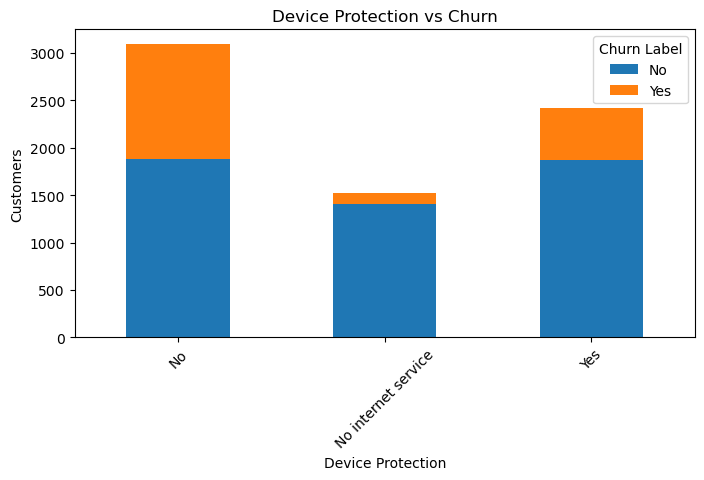

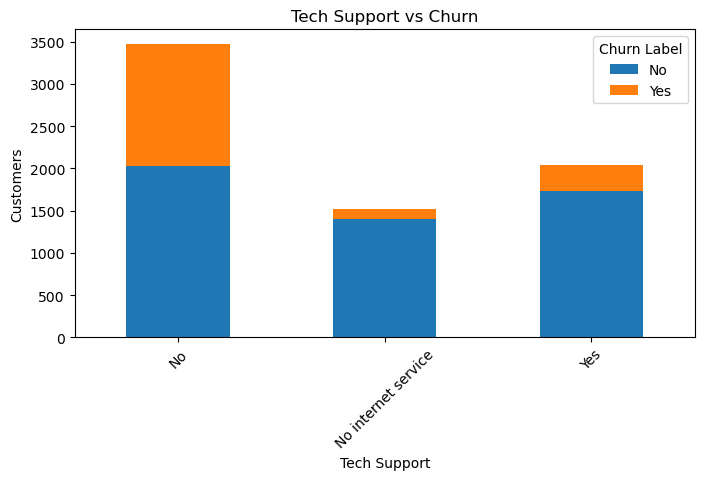

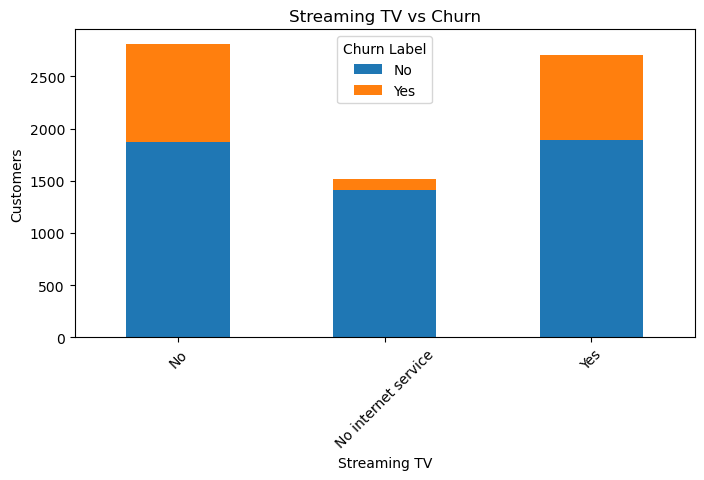

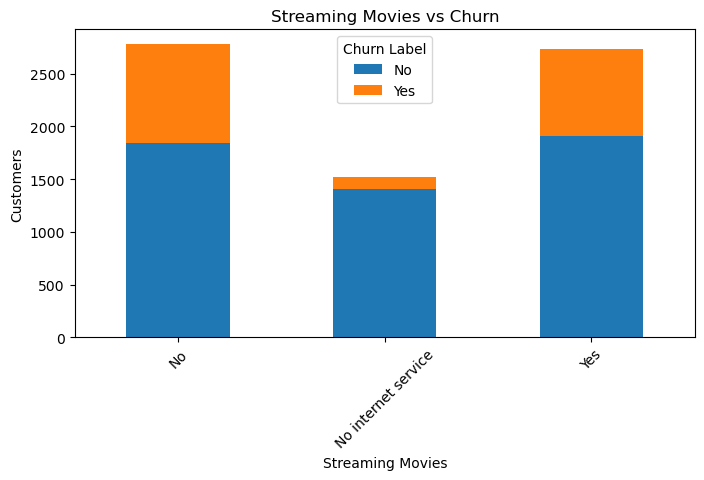

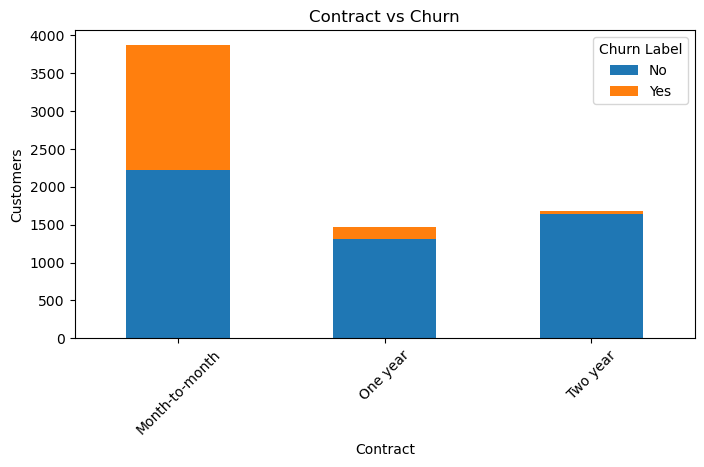

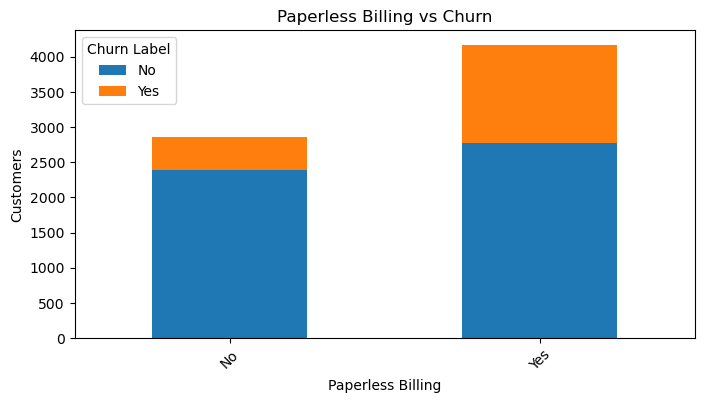

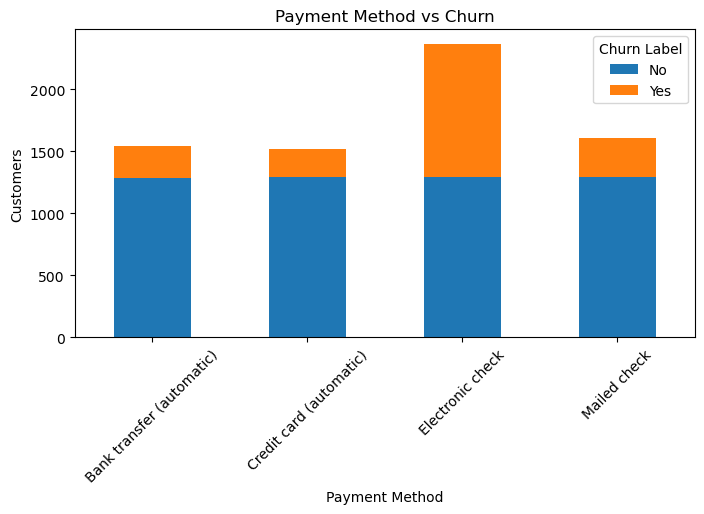

In [30]:
for feature in categorical_features:
    pd.crosstab(df[feature], df["Churn Label"]).plot(
        kind="bar",
        stacked=True,
        figsize=(8, 4)
    )
    plt.title(feature + " vs Churn")
    plt.ylabel("Customers")
    plt.xticks(rotation=45)
    plt.show()

# Bivariate Analysis: Numerical Features vs Churn

In [31]:
for feature in numerical_features:
    print("=" * 60)
    print(feature)
    print("=" * 60)
    print(df.groupby("Churn Label")[feature].describe())
    print("\n")

Tenure Months
              count       mean        std  min   25%   50%   75%   max
Churn Label                                                           
No           5163.0  37.650010  24.076940  1.0  15.0  38.0  61.0  72.0
Yes          1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


Monthly Charges
              count       mean        std    min    25%    50%     75%     max
Churn Label                                                                   
No           5163.0  61.307408  31.094557  18.25  25.10  64.45  88.475  118.75
Yes          1869.0  74.441332  24.666053  18.85  56.15  79.65  94.200  118.35


Total Charges
              count         mean          std    min      25%      50%  \
Churn Label                                                              
No           5163.0  2555.344141  2329.456984  18.80  577.825  1683.60   
Yes          1869.0  1531.796094  1890.822994  18.85  134.500   703.55   

                  75%      max  
Churn Label           

<Figure size 700x400 with 0 Axes>

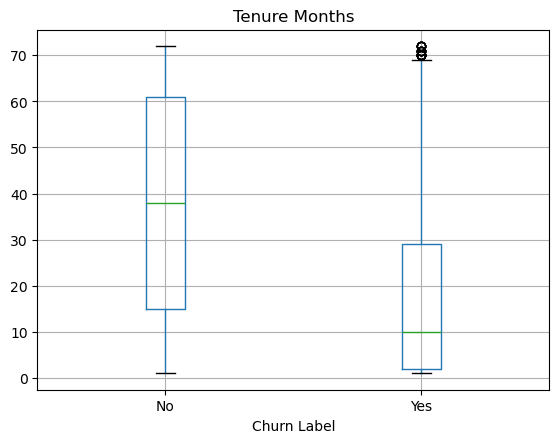

<Figure size 700x400 with 0 Axes>

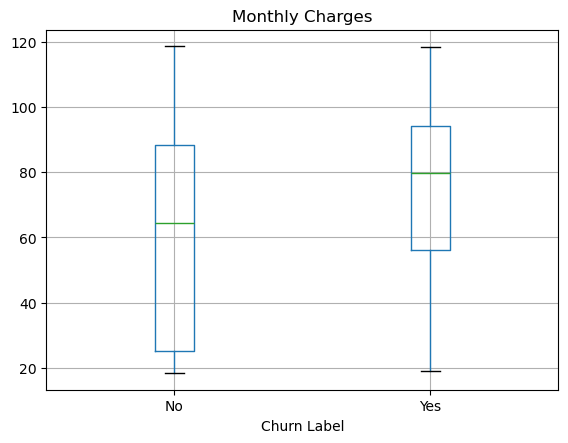

<Figure size 700x400 with 0 Axes>

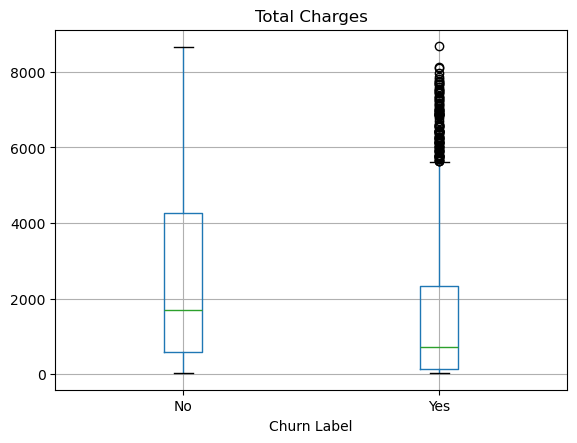

<Figure size 700x400 with 0 Axes>

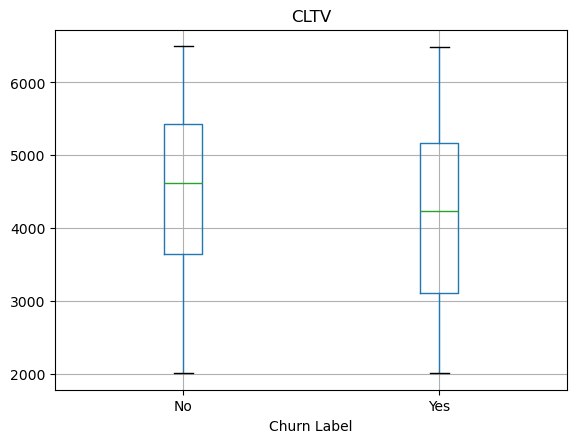

In [32]:
# BoxPlots
for feature in numerical_features:
    plt.figure(figsize=(7, 4))
    df.boxplot(column=feature, by="Churn Label")
    plt.title(feature)
    plt.suptitle("")
    plt.show()

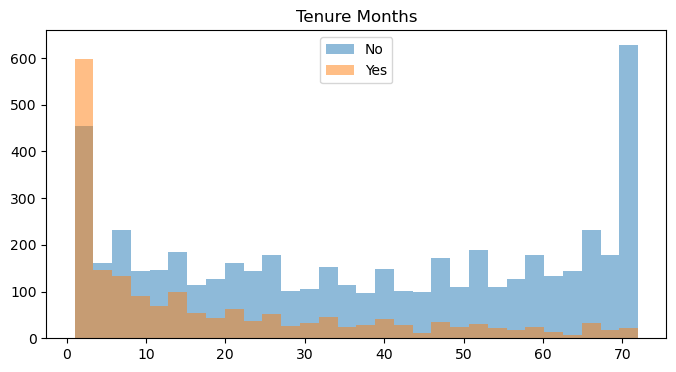

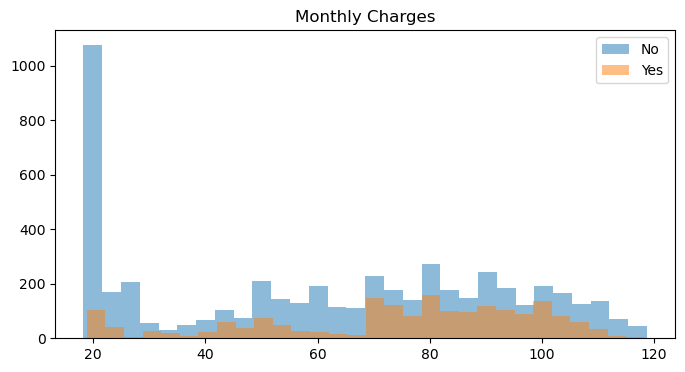

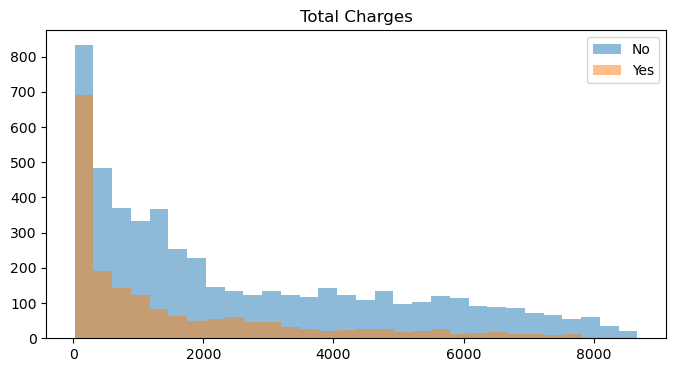

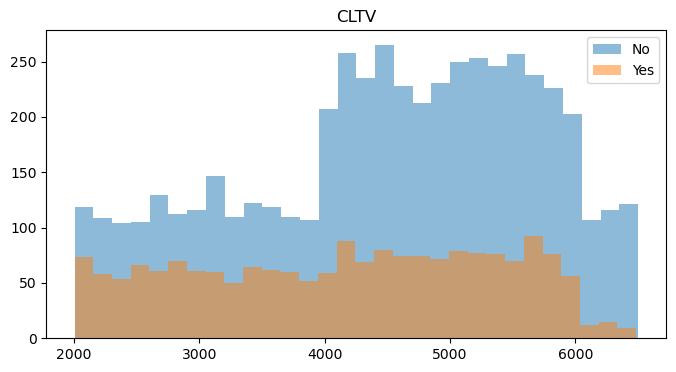

In [33]:
# Histogram
for feature in numerical_features:
    plt.figure(figsize=(8, 4))

    plt.hist(
        df[df["Churn Label"] == "No"][feature],
        alpha=0.5,
        bins=30,
        label="No"
    )
    plt.hist(
        df[df["Churn Label"] == "Yes"][feature],
        alpha=0.5,
        bins=30,
        label="Yes"
    )

    plt.legend()
    plt.title(feature)
    plt.show()

# Multivariate Analysis & Correlations

In [34]:
correlation_matrix = df[numerical_features].corr()

correlation_matrix

,Tenure Months,Monthly Charges,Total Charges,CLTV
Tenure Months,1.000000,0.246862,0.825880,0.396188
Monthly Charges,0.246862,1.000000,0.651065,0.098565
Total Charges,0.825880,0.651065,1.000000,0.341837
CLTV,0.396188,0.098565,0.341837,1.000000


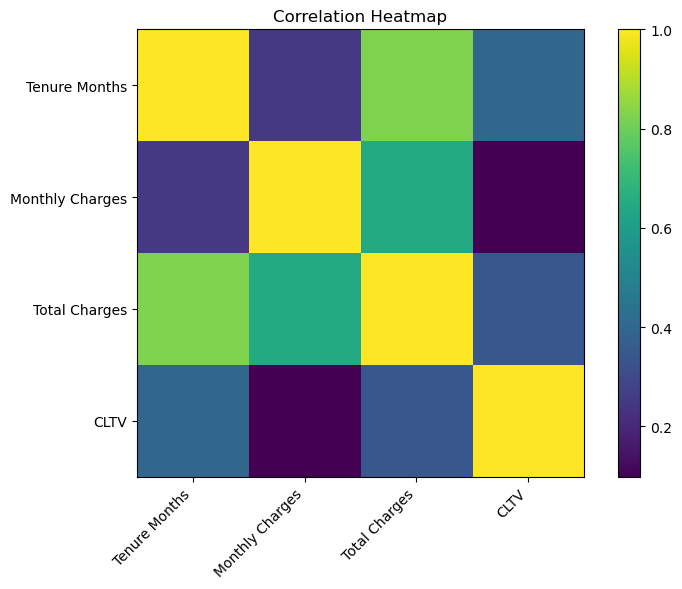

In [35]:
plt.figure(figsize=(8,6))

plt.imshow(correlation_matrix, interpolation="nearest")

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

In [36]:
threshold = 0.80

corr = correlation_matrix.abs()

high_correlation = [
    (corr.columns[i], corr.columns[j], corr.iloc[i, j])
    for i in range(len(corr.columns))
    for j in range(i)
    if corr.iloc[i, j] > threshold
]

high_correlation

[('Total Charges', 'Tenure Months', np.float64(0.8258804609331983))]

## Correlation Interpretation

`Total Charges` correlates strongly with both `Tenure Months` and `Monthly
Charges` (see scatter plots below). This is expected: longer-tenure customers
accumulate higher total charges. The multicollinearity is generally acceptable
for tree-based models, but worth keeping in mind for linear models.

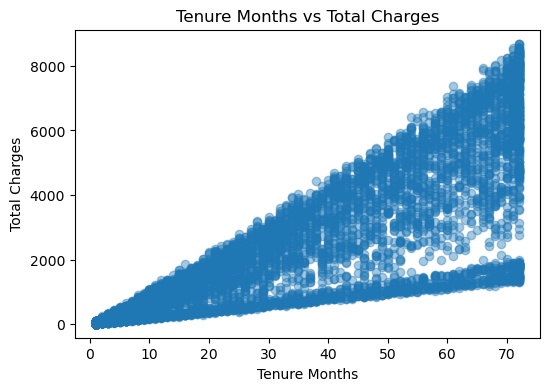

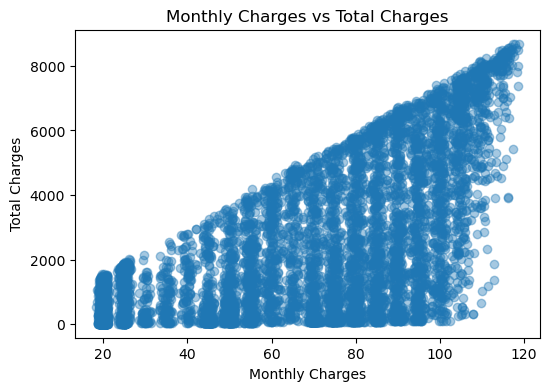

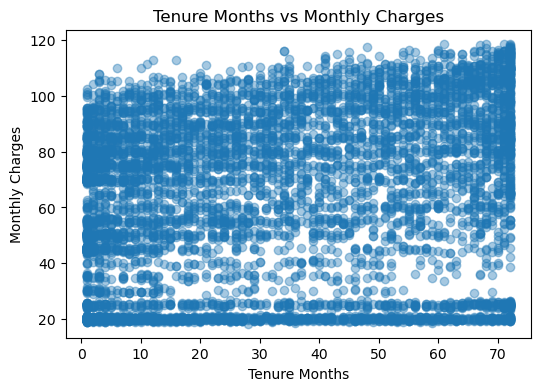

In [37]:
pairs = [
    ("Tenure Months", "Total Charges"),
    ("Monthly Charges", "Total Charges"),
    ("Tenure Months", "Monthly Charges")
]

for x, y in pairs:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[x], df[y], alpha=0.4)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")
    plt.show()

## Key Takeaways

- The target is moderately imbalanced (~26% churn) - use Precision, Recall, and F1-score.
- `CustomerID`, `Count`, `Country`, `State` are identifiers/constants and are dropped downstream.
- `Churn Score` and `Churn Reason` leak the target and must never reach the model.
- `Total Charges` needs type coercion (11 blanks, all with `Tenure Months` = 0).
- `CLTV` is treated as a business metric, not a model feature.